In [1]:
!pip install seaborn
!pip install torch
!pip install torchvision
!pip install scikit-learn
!pip install timm

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


Detected Classes: ['DeepFakeDetection', 'FaceShifter', 'FaceSwap', 'NeuraTextures', 'deepfakes', 'face2face', 'original']
Number of Classes: 7
[Epoch 1/20] [Batch 1531 / 1531] [Loss: 1.825537, Acc: 24.94%]
Evaluating...
[Batch 219 / 219]  [Loss: 1.710454, Acc: 29.75%]
Average Accuracy: 29.75%
Saving best model with validation accuracy: 29.75%
[Epoch 2/20] [Batch 1531 / 1531] [Loss: 1.657044, Acc: 33.10%]
Evaluating...
[Batch 219 / 219]  [Loss: 1.591669, Acc: 34.72%]
Average Accuracy: 34.72%
Saving best model with validation accuracy: 34.72%
[Epoch 3/20] [Batch 1531 / 1531] [Loss: 1.579935, Acc: 37.05%]
Evaluating...
[Batch 219 / 219]  [Loss: 1.531535, Acc: 37.53%]
Average Accuracy: 37.53%
Saving best model with validation accuracy: 37.53%
[Epoch 4/20] [Batch 1531 / 1531] [Loss: 1.512949, Acc: 40.18%]
Evaluating...
[Batch 219 / 219]  [Loss: 1.461956, Acc: 40.84%]
Average Accuracy: 40.84%
Saving best model with validation accuracy: 40.84%
[Epoch 5/20] [Batch 1531 / 1531] [Loss: 1.452310,

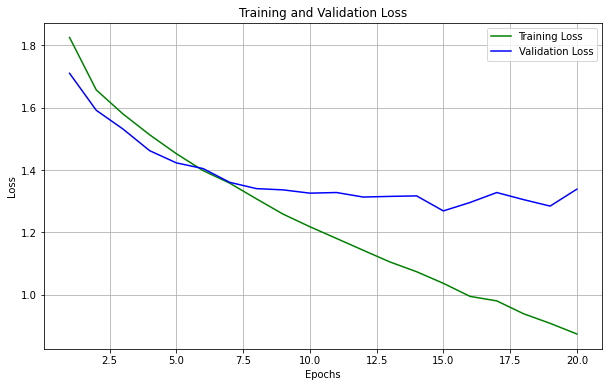

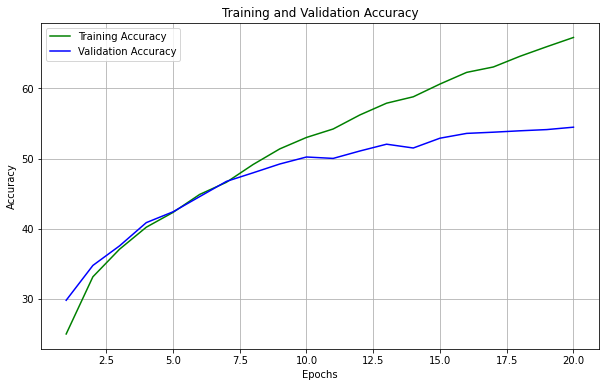


--- Evaluating on Test Set ---

Evaluating...
[Batch 438 / 438]  [Loss: 1.234476, Acc: 56.18%]
Average Accuracy: 56.18%


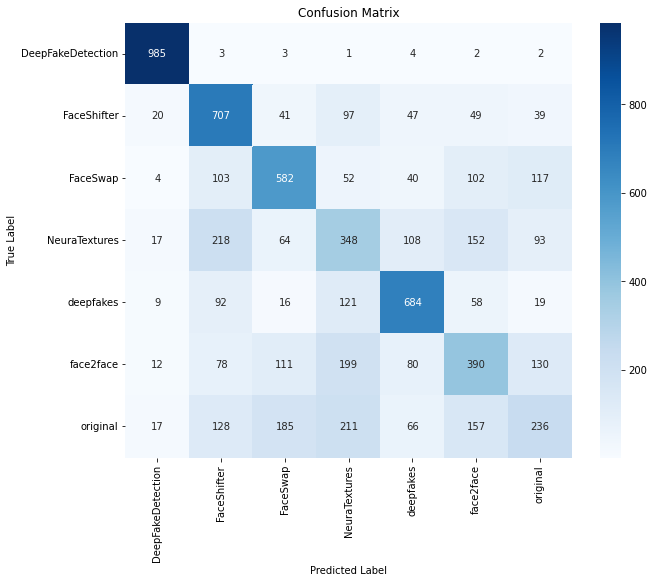

Test Accuracy: 56.18%
Test Loss: 1.2345


In [5]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import os
import sys

# Define the paths to your dataset
TRAIN_DIR = "./face_extraction/faceforensis_face_extract/train"
VAL_DIR = "./face_extraction/faceforensis_face_extract/val/"
TEST_DIR = "./face_extraction/faceforensis_face_extract/test/"

# Define image transformations
# MobileNetV3 expects 224x224 input
# Normalization parameters are standard for ImageNet pre-trained models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)

# Get class names
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Detected Classes: {class_names}")
print(f"Number of Classes: {num_classes}")

# Create data loaders
batch_size = 16 # You can adjust this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Model Definition
class Model(nn.Module):
    def __init__(self, num_classes, latent_dim=960):
        super(Model, self).__init__()
        # Load MobileNetV3-Large with pre-trained weights
        model = models.mobilenet_v3_large(weights='IMAGENET1K_V1') # Using 'weights' as 'pretrained' is deprecated
        # Remove the classifier (last two layers) and the average pooling layer
        # We need the feature extractor part
        self.features = nn.Sequential(*list(model.features.children()))
        
        # Adaptive average pooling to get a fixed-size output for the classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier
        # The last layer of MobileNetV3 large features has 960 output channels
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, num_classes)
        )
        
    def forward(self, x):
        # Apply the feature extractor
        x = self.features(x)
        # Apply adaptive average pooling
        x = self.avgpool(x)
        # Flatten the output for the linear layer
        x = x.view(x.size(0), -1) # Flatten to (batch_size, 960)
        # Pass through the classifier
        output = self.classifier(x)
        return output

# Initialize the model, optimizer, and criterion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(num_classes=num_classes).to(device)

# Hyperparameters
lr = 1e-5
num_epochs = 20 # As per your example code
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss().to(device)

# Helper classes and functions (from your original code, adapted for multi-class)
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def calculate_accuracy(outputs, targets):
    batch_size = targets.size(0)
    _, pred = outputs.topk(1, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.float().sum().item()
    return 100 * n_correct_elems / batch_size

def train_epoch(epoch, epochs_count, data_loader, model, criterion, optimizer):
    model.train()
    average_losses = AverageMeter()
    average_accuracy = AverageMeter()
    
    for i, (inputs, targets) in enumerate(data_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        accuracy = calculate_accuracy(outputs, targets)

        average_losses.update(loss.item(), inputs.size(0))
        average_accuracy.update(accuracy, inputs.size(0))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sys.stdout.write(
            "\r[Epoch %d/%d] [Batch %d / %d] [Loss: %f, Acc: %.2f%%]"
            % (
                epoch,
                epochs_count,
                i + 1,
                len(data_loader),
                average_losses.avg,
                average_accuracy.avg
            )
        )
    return average_losses.avg, average_accuracy.avg

def evaluate_model(epoch, model, data_loader, criterion):
    print('\nEvaluating...')
    model.eval()
    average_losses = AverageMeter()
    average_accuracy = AverageMeter()
    all_predictions = []
    all_actual_values = []
    
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(data_loader):
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            accuracy = calculate_accuracy(outputs, targets)
            
            _, predicted = torch.max(outputs, 1)
            all_actual_values.extend(targets.cpu().numpy().tolist())
            all_predictions.extend(predicted.cpu().numpy().tolist())

            average_losses.update(loss.item(), inputs.size(0))
            average_accuracy.update(accuracy, inputs.size(0))

            sys.stdout.write(
                "\r[Batch %d / %d]  [Loss: %f, Acc: %.2f%%]"
                % (
                    i + 1,
                    len(data_loader),
                    average_losses.avg,
                    average_accuracy.avg
                )
            )
        print(f'\nAverage Accuracy: {average_accuracy.avg:.2f}%')
    return all_actual_values, all_predictions, average_losses.avg, average_accuracy.avg

def plot_metrics(train_metrics, val_metrics, metric_name, num_epochs):
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_metrics, 'g', label=f'Training {metric_name}')
    plt.plot(epochs, val_metrics, 'b', label=f'Validation {metric_name}')
    plt.title(f'Training and Validation {metric_name}')
    plt.xlabel('Epochs')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True)
    plt.show()

def print_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Training Loop
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0.0
best_model_path = 'best_model_multiclass.h5'

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    # Train
    train_loss, train_acc = train_epoch(epoch, num_epochs, train_loader, model, criterion, optimizer)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validate
    actual_val, predicted_val, val_loss, val_acc = evaluate_model(epoch, model, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save the best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Saving best model with validation accuracy: {best_val_accuracy:.2f}%")

end_time = time.time()
training_time = end_time - start_time
print(f"\nTraining completed in {training_time:.2f} seconds.")

# Plotting loss and accuracy
plot_metrics(train_losses, val_losses, 'Loss', num_epochs)
plot_metrics(train_accuracies, val_accuracies, 'Accuracy', num_epochs)

# Evaluate on the test set and display confusion matrix
print("\n--- Evaluating on Test Set ---")
actual_test, predicted_test, test_loss, test_accuracy = evaluate_model("Final", model, test_loader, criterion)
print_confusion_matrix(actual_test, predicted_test, class_names)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

In [6]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Verifique se precisa das probabilidades para o AUC
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# F1-score (macro)
f1 = f1_score(all_labels, all_preds, average='macro')

# Acurácia geral
acc = np.mean(np.array(all_preds) == np.array(all_labels))

# Relatório por classe
report = classification_report(all_labels, all_preds, target_names=list(train_dataset.class_to_idx.keys()), zero_division=0)
print("\nClassification Report:\n", report)

# Métricas globais
print(f"\nFinal Evaluation:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  F1-score:  {f1:.4f}")


NameError: name 'all_preds' is not defined